## Sampling Method Comparison

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

/opt/conda/lib/python3.7/site-packages/statsmodels/tools/_testing.py:19: FutureWarning: pandas.util.testing is deprecated. Use the functions in the public API at pandas.testing instead.
  import pandas.util.testing as tm


### 1. Data

#### 1.1. Load Data

In [2]:
housing = pd.read_csv('housing.csv')

In [3]:
housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


#### 1.2. Review Data

/opt/conda/lib/python3.7/site-packages/numpy/lib/histograms.py:829: RuntimeWarning: invalid value encountered in greater_equal
  keep = (tmp_a >= first_edge)
/opt/conda/lib/python3.7/site-packages/numpy/lib/histograms.py:830: RuntimeWarning: invalid value encountered in less_equal
  keep &= (tmp_a <= last_edge)


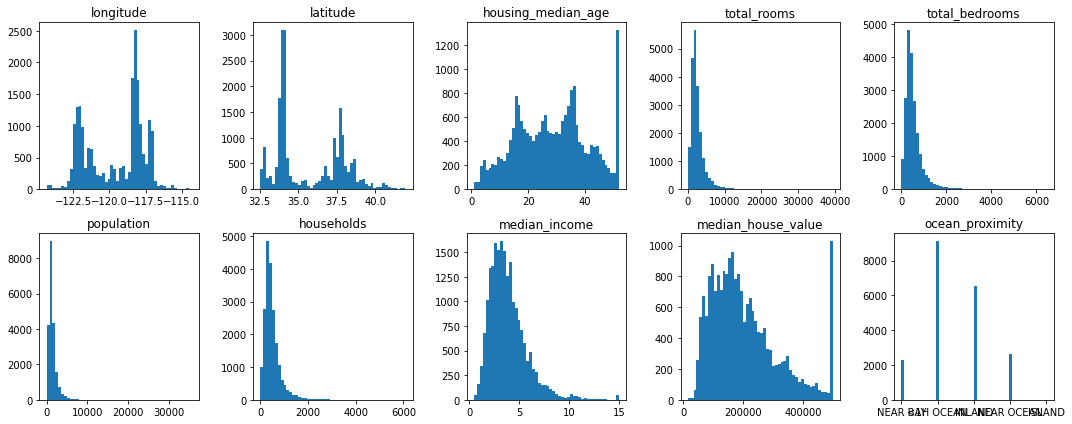

In [4]:
fig, axes = plt.subplots(ncols=5, nrows=2, figsize=(15,6))
ax = axes.ravel()

for i, axi in enumerate(ax):
    axi.hist(housing[housing.columns[i]], bins=50)
    axi.set_title(housing.columns[i])

fig.tight_layout()

In [5]:
housing['ocean_proximity'].value_counts()

<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: ocean_proximity, dtype: int64

#### 1.3. Reduce Data

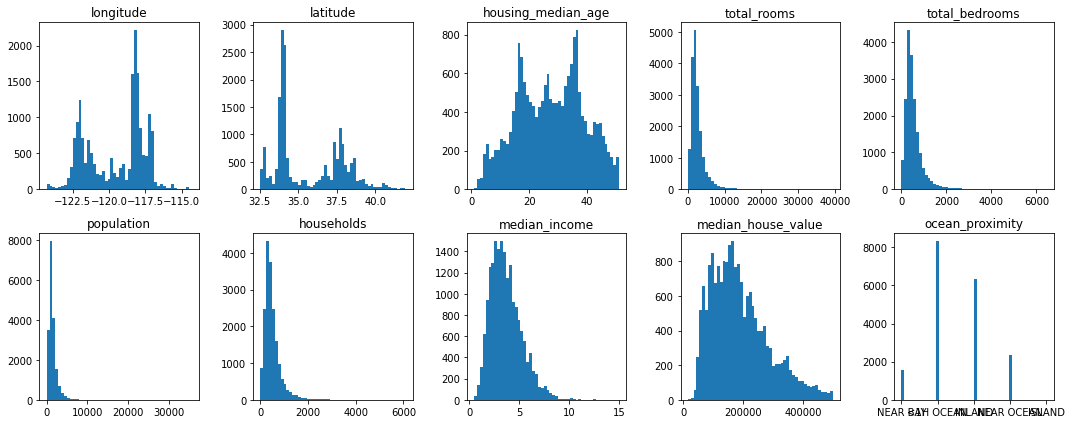

In [6]:
housing_r = housing.copy()
housing_r = housing_r[housing_r["housing_median_age"] < housing_r["housing_median_age"].max()]
housing_r = housing_r[housing_r["median_house_value"] < housing_r["median_house_value"].max()]

fig, axes = plt.subplots(ncols=5, nrows=2, figsize=(15,6))
ax = axes.ravel()

for i, axi in enumerate(ax):
    axi.hist(housing_r[housing_r.columns[i]], bins=50)
    axi.set_title(housing_r.columns[i])

fig.tight_layout()

In [7]:
housing_r['ocean_proximity'].value_counts()

<1H OCEAN     8331
INLAND        6344
NEAR OCEAN    2328
NEAR BAY      1567
ISLAND           2
Name: ocean_proximity, dtype: int64

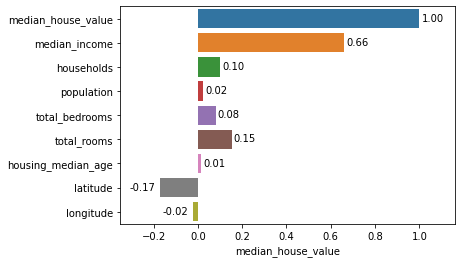

In [8]:
columns = list(housing_r)
columns.reverse()

cor = housing_r[columns].corr()

fig, ax = plt.subplots()
sns.barplot(cor['median_house_value'], cor.index, ax=ax)

xlim_min = np.inf
xlim_max = -np.inf
for patch in ax.patches:
    if patch.get_width() >= 0:
        text_x = patch.get_width()+0.06
    else:
        text_x = patch.get_width()-0.08
        
    if text_x > xlim_max:
        xlim_max = text_x
    if text_x < xlim_min:
        xlim_min = text_x
    text_y = patch.get_y()+0.5
    text = f'{patch.get_width():0.2f}'
    ax.text(text_x, text_y, text, ha='center')
ax.set_xlim(xlim_min-0.1, xlim_max+0.1)
plt.show()

### 2. Data Preprocessing

#### 2.1. Data Quantization : 'median_income'

In [9]:
housing_r['income_cat'] = pd.cut(
    housing_r['median_income'], bins=[0, 2, 4, 6, 8, np.inf], labels=[1, 2, 3, 4, 5]
)

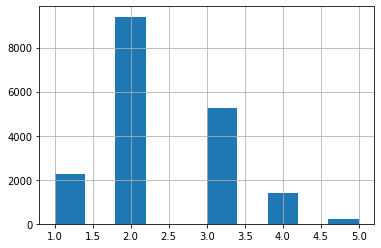

In [10]:
housing_r['income_cat'].hist();

#### 2.2. Onehot Encoding

In [11]:
housing_r['ocean_proximity'].value_counts()

<1H OCEAN     8331
INLAND        6344
NEAR OCEAN    2328
NEAR BAY      1567
ISLAND           2
Name: ocean_proximity, dtype: int64

In [12]:
housing_r = pd.get_dummies(housing_r, prefix=['ocean_proximity'], columns = ['ocean_proximity'])
housing_r.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,income_cat,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,5,0,0,0,1,0
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,5,0,0,0,1,0
8,-122.26,37.84,42.0,2555.0,665.0,1206.0,595.0,2.0804,226700.0,2,0,0,0,1,0
15,-122.26,37.85,50.0,1120.0,283.0,697.0,264.0,2.1250,140000.0,2,0,0,0,1,0
18,-122.26,37.84,50.0,2239.0,455.0,990.0,419.0,1.9911,158700.0,1,0,0,0,1,0


In [13]:
# # scikit-learn Onehot Encoder
# from sklearn.preprocessing import OneHotEncoder

# encoder = OneHotEncoder()
# transformed = encoder.transform(data['ocean_proximity'].to_numpy().reshape(-1, 1))

# #Create a Pandas DataFrame of the hot encoded column
# ohe_df = pd.DataFrame(transformed, columns=encoder.get_feature_names())

# #concat with original data
# housing_r = pd.concat([housing_r, ohe_df], axis=1).drop(['ocean_proximity'], axis=1)

#### 2.3. Missing data imputation

In [14]:
housing_r.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 18572 entries, 0 to 20639
Data columns (total 15 columns):
 #   Column                      Non-Null Count  Dtype   
---  ------                      --------------  -----   
 0   longitude                   18572 non-null  float64 
 1   latitude                    18572 non-null  float64 
 2   housing_median_age          18572 non-null  float64 
 3   total_rooms                 18572 non-null  float64 
 4   total_bedrooms              18379 non-null  float64 
 5   population                  18572 non-null  float64 
 6   households                  18572 non-null  float64 
 7   median_income               18572 non-null  float64 
 8   median_house_value          18572 non-null  float64 
 9   income_cat                  18572 non-null  category
 10  ocean_proximity_<1H OCEAN   18572 non-null  uint8   
 11  ocean_proximity_INLAND      18572 non-null  uint8   
 12  ocean_proximity_ISLAND      18572 non-null  uint8   
 13  ocean_proximity_

In [15]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='mean')
values = housing_r.values
transformed_values = imputer.fit_transform(housing_r)

housing_r = pd.DataFrame(data=transformed_values,
                         columns=housing_r.columns
                        )

housing_r.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18572 entries, 0 to 18571
Data columns (total 15 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   longitude                   18572 non-null  float64
 1   latitude                    18572 non-null  float64
 2   housing_median_age          18572 non-null  float64
 3   total_rooms                 18572 non-null  float64
 4   total_bedrooms              18572 non-null  float64
 5   population                  18572 non-null  float64
 6   households                  18572 non-null  float64
 7   median_income               18572 non-null  float64
 8   median_house_value          18572 non-null  float64
 9   income_cat                  18572 non-null  float64
 10  ocean_proximity_<1H OCEAN   18572 non-null  float64
 11  ocean_proximity_INLAND      18572 non-null  float64
 12  ocean_proximity_ISLAND      18572 non-null  float64
 13  ocean_proximity_NEAR BAY    185

### 3. Sampling

#### 2.2. Random Sampling

In [16]:
from sklearn.model_selection import train_test_split

train_random, test_random = train_test_split(housing_r, test_size=0.3, random_state=42)

#### 2.3. Stratified Sampling: 'income_cat'

In [17]:
train_strat, test_strat = train_test_split(housing_r, test_size=0.3, random_state=42, stratify=housing_r['income_cat'])

#### 2.4. Sampling Comparison

In [18]:
def income_cat_proportions(housing_r):
    return housing_r["income_cat"].value_counts() / len(housing_r)


compare_props = pd.DataFrame(
    {
        "Random": test_random["income_cat"].value_counts(),
        "Stratified": test_strat["income_cat"].value_counts(),
        "Overall (%)": income_cat_proportions(housing_r) * 100,
        "Random (%)": income_cat_proportions(test_random) * 100,
        "Stratified (%)": income_cat_proportions(test_strat) * 100,
    }
).sort_index()

compare_props["Random %err"] = (
    100 * compare_props["Random (%)"] / compare_props["Overall (%)"] - 100
)
compare_props["Stratified %err"] = (
    100 * compare_props["Stratified (%)"] / compare_props["Overall (%)"] - 100
)

compare_props

,Random,Stratified,Overall (%),Random (%),Stratified (%),Random %err,Stratified %err
1.0,698,675,12.115012,12.526920,12.114142,3.399984,-0.007179
2.0,2817,2821,50.629981,50.556353,50.628141,-0.145423,-0.003634
3.0,1556,1583,28.419126,27.925341,28.409907,-1.737508,-0.032439
4.0,435,423,7.586690,7.806892,7.591529,2.902478,0.063788
5.0,66,70,1.249192,1.184494,1.256281,-5.179221,0.567493


#### 2.5. Data Restoration : 'median_income'

In [19]:
train_random.drop("income_cat", axis=1, inplace=True)
test_random.drop("income_cat", axis=1, inplace=True)
train_strat.drop("income_cat", axis=1, inplace=True)
test_strat.drop("income_cat", axis=1, inplace=True)

/opt/conda/lib/python3.7/site-packages/pandas/core/frame.py:3997: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  errors=errors,


### 3. Machine Learning

In [20]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

#### 3.1. Training and Testing data split

In [21]:
Y_train_random = train_random['median_house_value']
X_train_random = train_random.drop('median_house_value', axis=1)

Y_test_random = test_random['median_house_value']
X_test_random = test_random.drop('median_house_value', axis=1)

In [22]:
Y_train_strat = train_strat['median_house_value']
X_train_strat = train_strat.drop('median_house_value', axis=1)

Y_test_strat = test_strat['median_house_value']
X_test_strat = test_strat.drop('median_house_value', axis=1)

#### 3.2. Random Sampling

In [23]:
rf_random = RandomForestRegressor(n_estimators=30, max_features=8, random_state=42)
rf_random.fit(X_train_random, Y_train_random)
Y_pred_random = rf_random.predict(X_test_random)
r2_random = r2_score(Y_pred_random, Y_test_random)
print(r2_random)

0.7143326996559467


#### 3.3. Stratified Sampling

In [24]:
rf_strat = RandomForestRegressor(n_estimators=30, max_features=8, random_state=42)
rf_strat.fit(X_train_strat, Y_train_strat)
Y_pred_strat = rf_random.predict(X_test_strat)
r2_strat = r2_score(Y_pred_strat, Y_test_strat)
print(r2_strat)

0.8962987992054889


#### 3.4. Visualization

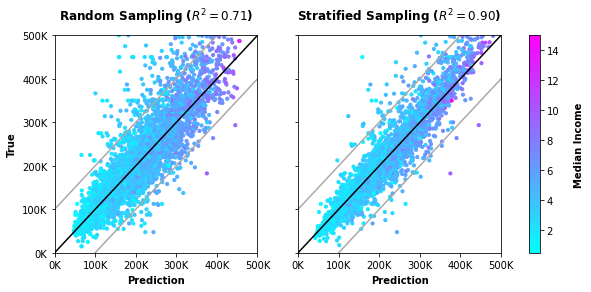

In [26]:
fig, ax = plt.subplots(ncols=2, figsize=(10,4), sharex=True, sharey=True)

ax[0].scatter(Y_pred_random, Y_test_random, c=X_test_random['median_income'], cmap='cool', s=10)
im = ax[1].scatter(Y_pred_strat, Y_test_strat, c=X_test_strat['median_income'], cmap='cool', s=10)

ax[0].plot([0,500000], [0,500000], c='k')
ax[1].plot([0,500000], [0,500000], c='k')
ax[0].plot([100000,500000], [0,400000], c='darkgray')
ax[0].plot([0,400000], [100000,500000], c='darkgray')
ax[1].plot([100000,500000], [0,400000], c='darkgray')
ax[1].plot([0,400000], [100000,500000], c='darkgray')

ax[0].set_xlim(0, 500000)
ax[0].set_ylim(0, 500000)

ax[0].set_xlabel('Prediction', fontweight='bold', labelpad=5)
ax[1].set_xlabel('Prediction', fontweight='bold', labelpad=5)
ax[0].set_ylabel('True', fontweight='bold', labelpad=5)

ticks = ax[0].get_xticks()
ticks_K = [f'{tick/1000:0.0f}K' for tick in ticks]
ax[0].set_xticklabels(ticks_K)
ax[0].set_yticklabels(ticks_K)
ax[1].set_xticklabels(ticks_K)

ax[0].set_title(f'Random Sampling ($R^2={r2_random:0.2f}$)', fontweight='bold', pad=15)
ax[1].set_title(f'Stratified Sampling ($R^2={r2_strat:0.2f}$)', fontweight='bold', pad=15)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Median Income', fontweight='bold', labelpad=15)
# fig.tight_layout(rect=(0,0,0.75,1))
fig.savefig('13_comp.png')
plt.show()